In [ ]:
from pathlib import Path

DATA_DIR  = Path('path_to_processed_data')
TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'valid'
TEST_DIR  = DATA_DIR / 'test'

In [ ]:
import sys, os
REPO_PATH = 'path_to_repo'
sys.path.insert(0, REPO_PATH)
os.chdir(REPO_PATH)

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from torch.utils.data import DataLoader

from data.utils import get_datasets, precompute_features
from data.dataset import CachedDataset
from models.train import train, predict
from models.evaluate import evaluate
from models.transformer import Transformer
from models.cnn_transformer import CNNTransformer
from models.utils import set_seed
from plots import plot_f1_training_curves, build_summary_df, plot_summary_table, plot_metrics_comparison, plot_confusion_matrix, plot_loss_and_f1_curves
EXPERIMENT_PATH = os.path.join(REPO_PATH, 'experiments/transformer_architecture')
sys.path.insert(0, EXPERIMENT_PATH)
from embeddings_plots import extract_embeddings, get_best_model, plot_tsne_comparison
from pooling_plots import extract_attention_weights, plot_attention_heatmap_comparison, plot_attention_profiles

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device)

Using device: cuda


In [17]:
SEEDS = [0, 1, 2]
EPOCHS = 30
BATCH_SIZE = 64
LR = 3e-4
REPR = "mfcc"
D_MODEL = 128
N_HEADS = [1, 2, 4, 8]
CLASS_NAMES = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go", "unknown", "silence"]

In [4]:
train_ds, valid_ds, test_ds = get_datasets(data_format=REPR, train_path=TRAIN_DIR, valid_path=VALID_DIR, test_path=TEST_DIR)
precompute_features(train_ds, Path('/kaggle/working/cache/train_mfcc'))
precompute_features(valid_ds, Path('/kaggle/working/cache/valid_mfcc'))
precompute_features(test_ds,  Path('/kaggle/working/cache/test_mfcc'))

train_cached = CachedDataset('/kaggle/working/cache/train_mfcc')
valid_cached = CachedDataset('/kaggle/working/cache/valid_mfcc')
test_cached  = CachedDataset('/kaggle/working/cache/test_mfcc')

  0%|          | 0/51486 [00:00<?, ?it/s]

Saved 51486 samples to /kaggle/working/cache/train_mfcc


  0%|          | 0/6828 [00:00<?, ?it/s]

Saved 6828 samples to /kaggle/working/cache/valid_mfcc


  0%|          | 0/6865 [00:00<?, ?it/s]

Saved 6865 samples to /kaggle/working/cache/test_mfcc


In [18]:
def run_nhead_experiment(model_factory, n_heads, seeds, d_model=D_MODEL, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, device=device, model_name='Model'):
    """
    Trains and evaluates model_factory(nhead) for each nhead x seed combination.

    Args:
        model_factory: callable(nhead: int) -> nn.Module
        n_heads: list of int
        seeds: list of int
        d_model: used only for divisibility check log
        model_name: used for print logs

    Returns:
        results[nhead][seed] = {
            'history', 'valid_acc', 'valid_loss', 'valid_f1',
            'test_acc', 'test_macro_f1', 'test_weighted_f1',
            'test_cm', 'model'
        }
    """
    results = {}

    for nhead in n_heads:
        if d_model % nhead != 0:
            print(f'Skipping nhead={nhead}: d_model={d_model} not divisible by nhead')
            continue
        results[nhead] = {}
        for seed in seeds:
            print(f'\n[{model_name}] nhead={nhead} | seed={seed}')
            print('-' * 50)
            set_seed(seed)

            model = model_factory(nhead).to(device)
            model, history = train(model, train_cached, valid_cached, epochs=epochs, batch_size=batch_size,
                                   lr=lr, device=str(device), verbose=True, verbose_interval=5)

            preds, labels = predict(model, test_cached, device=str(device), batch_size=batch_size)
            test_results  = evaluate(preds, labels, print_report=False)

            results[nhead][seed] = {
                'history': history,
                'valid_acc': history['valid_acc'][-1],
                'valid_loss': history['valid_loss'][-1],
                'valid_f1': history['valid_f1'][-1],
                'test_acc': test_results['acc'],
                'test_macro_f1': test_results['macro_f1'],
                'test_weighted_f1': test_results['weighted_f1'],
                'test_cm': test_results['cm'],
                'model': model,
            }

    return results

In [19]:
def transformer_nhead_factory(nhead):
    return Transformer(n_features=40, n_timesteps=101, num_classes=12, d_model=D_MODEL, nhead=nhead, num_layers=4,
                       dropout=0.1, pooling='mean')

def cnn_transformer_nhead_factory(nhead):
    return CNNTransformer(n_features=40, n_timesteps=101, num_classes=12, base_channels=32, d_model=D_MODEL, nhead=nhead,
                          num_layers=4, dropout=0.1, pooling='mean')

In [21]:
transformer_nhead_results = run_nhead_experiment(model_factory=transformer_nhead_factory, n_heads=N_HEADS, seeds=SEEDS,
    d_model=D_MODEL, model_name='Transformer',)


[Transformer] nhead=1 | seed=0
--------------------------------------------------
Epoch 5/30 | Train Loss: 0.1822 | Valid Loss: 0.2377 | Valid Acc: 0.9243 | Valid Macro F1: 0.8864
Epoch 10/30 | Train Loss: 0.0916 | Valid Loss: 0.1881 | Valid Acc: 0.9448 | Valid Macro F1: 0.9147
Epoch 15/30 | Train Loss: 0.0499 | Valid Loss: 0.2141 | Valid Acc: 0.9443 | Valid Macro F1: 0.9140
Epoch 20/30 | Train Loss: 0.0300 | Valid Loss: 0.2351 | Valid Acc: 0.9477 | Valid Macro F1: 0.9227
Epoch 25/30 | Train Loss: 0.0183 | Valid Loss: 0.2463 | Valid Acc: 0.9495 | Valid Macro F1: 0.9242
Epoch 30/30 | Train Loss: 0.0148 | Valid Loss: 0.2491 | Valid Acc: 0.9524 | Valid Macro F1: 0.9281
Best validation accuracy: 0.9531

[Transformer] nhead=1 | seed=1
--------------------------------------------------


/kaggle/input/datasets/zuzannasienko/transformers-speech-recognition/models/transformer.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(encoder_layer=encoder_layer, num_layers=num_layers)


Epoch 5/30 | Train Loss: 0.1837 | Valid Loss: 0.2521 | Valid Acc: 0.9230 | Valid Macro F1: 0.8846
Epoch 10/30 | Train Loss: 0.0929 | Valid Loss: 0.2164 | Valid Acc: 0.9398 | Valid Macro F1: 0.9070
Epoch 15/30 | Train Loss: 0.0499 | Valid Loss: 0.2202 | Valid Acc: 0.9489 | Valid Macro F1: 0.9219
Epoch 20/30 | Train Loss: 0.0298 | Valid Loss: 0.2345 | Valid Acc: 0.9501 | Valid Macro F1: 0.9226
Epoch 25/30 | Train Loss: 0.0190 | Valid Loss: 0.2404 | Valid Acc: 0.9498 | Valid Macro F1: 0.9226
Epoch 30/30 | Train Loss: 0.0159 | Valid Loss: 0.2438 | Valid Acc: 0.9521 | Valid Macro F1: 0.9256
Best validation accuracy: 0.9524

[Transformer] nhead=1 | seed=2
--------------------------------------------------


/kaggle/input/datasets/zuzannasienko/transformers-speech-recognition/models/transformer.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(encoder_layer=encoder_layer, num_layers=num_layers)


Epoch 5/30 | Train Loss: 0.1947 | Valid Loss: 0.2608 | Valid Acc: 0.9203 | Valid Macro F1: 0.8779
Epoch 10/30 | Train Loss: 0.1009 | Valid Loss: 0.2249 | Valid Acc: 0.9348 | Valid Macro F1: 0.9020
Epoch 15/30 | Train Loss: 0.0537 | Valid Loss: 0.2607 | Valid Acc: 0.9353 | Valid Macro F1: 0.8927
Epoch 20/30 | Train Loss: 0.0293 | Valid Loss: 0.2511 | Valid Acc: 0.9441 | Valid Macro F1: 0.9156
Epoch 25/30 | Train Loss: 0.0182 | Valid Loss: 0.2856 | Valid Acc: 0.9432 | Valid Macro F1: 0.9132
Epoch 30/30 | Train Loss: 0.0149 | Valid Loss: 0.2877 | Valid Acc: 0.9435 | Valid Macro F1: 0.9149
Best validation accuracy: 0.9441

[Transformer] nhead=2 | seed=0
--------------------------------------------------
Epoch 5/30 | Train Loss: 0.1573 | Valid Loss: 0.2169 | Valid Acc: 0.9376 | Valid Macro F1: 0.9063
Epoch 10/30 | Train Loss: 0.0794 | Valid Loss: 0.2036 | Valid Acc: 0.9460 | Valid Macro F1: 0.9173
Epoch 15/30 | Train Loss: 0.0447 | Valid Loss: 0.2327 | Valid Acc: 0.9402 | Valid Macro F1: 0.

In [ ]:
cnn_transformer_nhead_results = run_nhead_experiment(model_factory=cnn_transformer_nhead_factory, n_heads=N_HEADS,
    seeds=SEEDS, d_model=D_MODEL, model_name='CNNTransformer')

In [7]:
transformer_nhead_results = run_nhead_experiment(model_factory=transformer_nhead_factory, n_heads=N_HEADS, seeds=SEEDS,
    d_model=D_MODEL, model_name='Transformer',)


[Transformer] d_model=64 | seed=0
--------------------------------------------------
Epoch 5/30 | Train Loss: 0.2093 | Valid Loss: 0.2406 | Valid Acc: 0.9243 | Valid Macro F1: 0.8800
Epoch 10/30 | Train Loss: 0.1114 | Valid Loss: 0.1910 | Valid Acc: 0.9454 | Valid Macro F1: 0.9133
Epoch 15/30 | Train Loss: 0.0666 | Valid Loss: 0.1920 | Valid Acc: 0.9495 | Valid Macro F1: 0.9187
Epoch 20/30 | Train Loss: 0.0429 | Valid Loss: 0.1957 | Valid Acc: 0.9527 | Valid Macro F1: 0.9281
Epoch 25/30 | Train Loss: 0.0320 | Valid Loss: 0.2120 | Valid Acc: 0.9530 | Valid Macro F1: 0.9296
Epoch 30/30 | Train Loss: 0.0279 | Valid Loss: 0.2119 | Valid Acc: 0.9528 | Valid Macro F1: 0.9284
Best validation accuracy: 0.9530

[Transformer] d_model=64 | seed=1
--------------------------------------------------
Epoch 5/30 | Train Loss: 0.1987 | Valid Loss: 0.2310 | Valid Acc: 0.9288 | Valid Macro F1: 0.8944
Epoch 10/30 | Train Loss: 0.1038 | Valid Loss: 0.1890 | Valid Acc: 0.9463 | Valid Macro F1: 0.9172
Epoch

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.lines import Line2D
from sklearn.metrics import classification_report
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import pandas as pd

from data.dataset import CLASSES

PALETTE = {
    'train':   '#2E86AB',
    'valid':   '#E84855',
    'accent':  '#F5A623',
    'success': '#44BBA4',
    'bg':      '#FFFFFF',
    'grid':    '#E0E0E0',
}

plt.rcParams.update({
    'figure.facecolor':  PALETTE['bg'],
    'axes.facecolor':    PALETTE['bg'],
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        PALETTE['grid'],
    'grid.linestyle':    '--',
    'grid.alpha':        0.7,
    'font.family':       'sans-serif',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'legend.frameon':    False,
})


def plot_confusion_matrix(cm, classes=CLASSES, normalize=True, title='Confusion Matrix'):
    """
    Plot confusion matrix heatmap.

    Args:
        cm: confusion_matrix output from evaluate()
        classes: list of class names (default: CLASSES from dataset.py)
        normalize: if True, show percentages instead of counts
        title: plot title
    """
    if normalize:
        cm_plot = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-9)
        fmt, vmax = '.2f', 1.0
    else:
        cm_plot = cm
        fmt, vmax = 'd', None

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        cm_plot, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=classes, yticklabels=classes,
        vmin=0, vmax=vmax,
        linewidths=1, linecolor=PALETTE['grid'],
        ax=ax,
    )
    ax.set_title(title, fontsize=15, fontweight='bold', pad=16)
    ax.set_ylabel('True label', fontsize=12)
    ax.set_xlabel('Predicted label', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
    ax.grid(False)
    plt.tight_layout()
    plt.show()


def plot_per_class_metrics(labels, preds, classes=CLASSES, title='Per-class Metrics'):
    """
    Bar chart of per-class precision, recall, and F1,
    with value labels on top of each bar and legend placed below the title.
 
    Args:
        labels: true labels (numpy array)
        preds: predicted labels (numpy array)
        classes: list of class names
        title: plot title
    """
    report = classification_report(labels, preds, target_names=classes, output_dict=True)
 
    metrics = {
        'Precision': [report[c]['precision'] for c in classes],
        'Recall':    [report[c]['recall']    for c in classes],
        'F1':        [report[c]['f1-score']  for c in classes],
    }
    colors = sns.color_palette('deep', n_colors=3)
 
    x = np.arange(len(classes))
    width = 0.26
 
    fig, ax = plt.subplots(figsize=(14, 6))
 
    for i, (name, vals) in enumerate(metrics.items()):
        bars = ax.bar(x + i * width, vals, width, label=name, color=colors[i], alpha=0.9)
        for bar, val in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01,
                f'{val:.2f}',
                ha='center', va='bottom', fontsize=7, color='#333333'
            )
 
    ax.set_xticks(x + width)
    ax.set_xticklabels(classes, rotation=40, ha='right')
    ax.set_ylabel('Score')
    ax.set_xlabel('Class')
    ax.set_ylim(0, 1.12)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=32)
 
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, 1.08),
        ncol=3,
        fontsize=10,
    )
 
    plt.tight_layout()
    plt.show()


def plot_training_curves(history, title='Training History'):
    """
    Plot loss and accuracy curves for a single training run.
    Best validation accuracy epoch is highlighted on the accuracy plot.

    Args:
        history: dict with keys 'train_loss', 'valid_loss', 'train_acc', 'valid_acc'
                 (lists of values per epoch)
        title: plot title
    """
    epochs = range(1, len(history['train_loss']) + 1)
    best_epoch = int(np.argmax(history['valid_acc'])) + 1
    best_acc = max(history['valid_acc'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.02)

    ax1.plot(epochs, history['train_loss'], color=PALETTE['train'],  linewidth=2, label='Training Loss')
    ax1.plot(epochs, history['valid_loss'], color=PALETTE['valid'],  linewidth=2, linestyle='--', label='Validation Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(epochs, history['valid_acc'], color=PALETTE['valid'], linewidth=2, label='Validation Accuracy')
    ax2.axvline(best_epoch, color='gray', linestyle=':', linewidth=1.5)
    ax2.scatter([best_epoch], [best_acc], color=PALETTE['valid'], zorder=5)
    ax2.annotate(f'best: {best_acc:.3f}',
                 xy=(best_epoch, best_acc),
                 xytext=(8, -15), textcoords='offset points',
                 fontsize=9, color='gray')
    ax2.set_title('Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1)
    ax2.legend()

    plt.tight_layout()
    plt.show()


def plot_training_curves_multiseed(histories, title='Training History (mean ± std)'):
    """
    Plot mean ± std loss and accuracy across multiple seeds.
    Best mean validation accuracy epoch is highlighted on the accuracy plot.

    Args:
        histories: list of history dicts (one per seed), each with keys
                   'train_loss', 'valid_loss', 'train_acc', 'valid_acc'
        title: plot title
    """
    keys = ['train_loss', 'valid_loss', 'train_acc', 'valid_acc']
    stacked = {k: np.array([h[k] for h in histories]) for k in keys}
    epochs = range(1, stacked['train_loss'].shape[1] + 1)

    mean_valid_acc = stacked['valid_acc'].mean(axis=0)
    best_epoch = int(np.argmax(mean_valid_acc)) + 1
    best_acc = mean_valid_acc[best_epoch - 1]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.02)

    for key, color, label, ls in [
        ('train_loss', PALETTE['train'], 'Training Loss',   '-'),
        ('valid_loss', PALETTE['valid'], 'Validation Loss', '--'),
    ]:
        mean = stacked[key].mean(axis=0)
        std = stacked[key].std(axis=0)
        ax1.plot(epochs, mean, color=color, linewidth=2, label=label, linestyle=ls)
        ax1.fill_between(epochs, mean - std, mean + std, color=color, alpha=0.15)

    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    mean = stacked['valid_acc'].mean(axis=0)
    std = stacked['valid_acc'].std(axis=0)

    ax2.plot(epochs, mean, color=PALETTE['valid'], linewidth=2, label='Validation Accuracy')
    ax2.fill_between(epochs, mean - std, mean + std, color=PALETTE['valid'], alpha=0.15)
    ax2.axvline(best_epoch, color='gray', linestyle=':', linewidth=1.5)
    ax2.scatter([best_epoch], [best_acc], color=PALETTE['valid'], zorder=5)
    ax2.annotate(f'best: {best_acc:.3f}',
                 xy=(best_epoch, best_acc),
                 xytext=(8, -15), textcoords='offset points',
                 fontsize=9, color='gray')
    ax2.set_title('Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_ylim(0, 1)
    ax2.legend()

    plt.tight_layout()
    plt.show()


def plot_model_comparison(results_dict, metric='macro_f1', title=None):
    """
    Bar chart comparing multiple models on a single metric.

    Args:
        results_dict: dict mapping model_name -> evaluate() output dict
                      e.g. {'CNN': result_cnn, 'Transformer': result_tr, ...}
        metric: key from evaluate() output: 'acc', 'macro_f1', 'weighted_f1'
        title: plot title (auto-generated if None)
    """
    models = list(results_dict.keys())
    values = [results_dict[m][metric] for m in models]
    colors = sns.color_palette('deep', n_colors=len(models))

    fig, ax = plt.subplots(figsize=(8, 5))
    bars = ax.bar(models, values, color=colors, edgecolor='black', linewidth=0.6, width=0.5)

    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10,
        )

    ylabel = {'acc': 'Accuracy', 'macro_f1': 'Macro F1', 'weighted_f1': 'Weighted F1'}.get(metric, metric)
    ax.set_ylabel(ylabel)
    ax.set_ylim(max(0, min(values) - 0.05), min(1.0, max(values) + 0.06))
    ax.set_title(title or f'Model Comparison – {ylabel}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_metrics_comparison(summary_df, title='Accuracy, Macro F1 & Weighted F1 by Model x Representation'):
    """
    Grouped bar chart showing accuracy, macro F1, and weighted F1 side by sidefor each model x representation combination, with error bars from multiple seeds.

    Args:
        summary_df: DataFrame with columns:
            'Model', 'Representation',
            'Test Acc (mean)', 'Test Acc (std)',
            'Test Macro F1 (mean)', 'Test Macro F1 (std)',
            'Test Weighted F1 (mean)', 'Test Weighted F1 (std)'
        title: plot title
    """

    groups = [f"{r['Model']}\n({r['Representation'].upper()})"  for _, r in summary_df.iterrows()]
    n = len(groups)
    x = np.arange(n)
    width = 0.26

    metric_cols = [
        ('Test Acc (mean)',        'Test Acc (std)',        'Accuracy',     PALETTE['train']),
        ('Test Macro F1 (mean)',   'Test Macro F1 (std)',   'Macro F1',     PALETTE['valid']),
        ('Test Weighted F1 (mean)','Test Weighted F1 (std)','Weighted F1',  PALETTE['accent']),
    ]

    fig, ax = plt.subplots(figsize=(max(10, n * 1.8), 6))

    for i, (mean_col, std_col, label, color) in enumerate(metric_cols):
        means = summary_df[mean_col].values
        stds  = summary_df[std_col].values
        bars = ax.bar(x + i * width, means, width,
                      yerr=stds, capsize=4,
                      label=label, color=color,
                      edgecolor='black', linewidth=0.5, alpha=0.9)
        for bar, m, s in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + s + 0.006,
                    f'{m:.3f}', ha='center', va='bottom', fontsize=7)

    ax.set_xticks(x + width)
    ax.set_xticklabels(groups, fontsize=9)
    ax.set_ylabel('Score')
    ax.set_ylim(0, min(1.0, summary_df[[c for c, *_ in metric_cols]].values.max() + 0.08))
    ax.set_title(title, fontsize=14, fontweight='bold', pad=32)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3, fontsize=10)
    plt.tight_layout()
    plt.show()


def build_summary_df(results_dict_map):
    """
    Build a unified summary DataFrame (mean +- std across seeds) for multiple models and representations.

    Args:
        results_dict_map: dict mapping model_name -> results_dict
            results_dict[repr_name][seed] = {
                'test_acc', 'valid_acc',
                'test_macro_f1', 'test_weighted_f1'
            }

    Returns:
        summary_df (pandas DataFrame)
    """

    def safe_cv(mean, std):
        return std / mean if mean > 1e-8 else np.nan

    rows = []

    for model_name, results_dict in results_dict_map.items():
        for repr_name, seed_dict in results_dict.items():

            test_accs = [v['test_acc'] for v in seed_dict.values()]
            valid_accs = [v['valid_acc'] for v in seed_dict.values()]
            macro_f1s = [v.get('test_macro_f1', np.nan) for v in seed_dict.values()]
            weighted_f1s = [v.get('test_weighted_f1', np.nan) for v in seed_dict.values()]

            rows.append({
                'Model': model_name,
                'Representation': repr_name,

                'Valid Acc (mean)': np.mean(valid_accs),
                'Valid Acc (std)': np.std(valid_accs),
                'Valid Acc (cv)': safe_cv(np.mean(valid_accs), np.std(valid_accs)),

                'Test Acc (mean)': np.mean(test_accs),
                'Test Acc (std)': np.std(test_accs),
                'Test Acc (cv)': safe_cv(np.mean(test_accs), np.std(test_accs)),

                'Test Macro F1 (mean)': np.nanmean(macro_f1s),
                'Test Macro F1 (std)': np.nanstd(macro_f1s),
                'Test Macro F1 (cv)': safe_cv(np.nanmean(macro_f1s), np.nanstd(macro_f1s)),

                'Test Weighted F1 (mean)': np.nanmean(weighted_f1s),
                'Test Weighted F1 (std)': np.nanstd(weighted_f1s),
                'Test Weighted F1 (cv)': safe_cv(np.nanmean(weighted_f1s), np.nanstd(weighted_f1s))
            })

    return pd.DataFrame(rows)


def plot_summary_table(summary_df):
    """
    Render a styled summary table with Acc, Macro F1, and Weighted F1 (mean +- std).
    Highlights the best value in each metric column.

    Args:
        summary_df: same DataFrame as plot_metrics_comparison expects.

    Returns:
        display_df: formatted DataFrame
    """

    display_df = summary_df[['Model', 'Representation']].copy()
    for mean_col, std_col, cv_col, label in [
        ('Test Acc (mean)',         'Test Acc (std)',         'Test Acc (cv)',         'Test Acc'),
        ('Test Macro F1 (mean)',    'Test Macro F1 (std)',    'Test Macro F1 (cv)',    'Macro F1'),
        ('Test Weighted F1 (mean)', 'Test Weighted F1 (std)', 'Test Weighted F1 (cv)', 'Weighted F1'),
    ]:
        display_df[label] = summary_df.apply(
            lambda r: f"{r[mean_col]:.4f} ± {r[std_col]:.4f}", axis=1
        )
        display_df[label + ' CV'] = summary_df[cv_col].apply(
            lambda x: f"{x:.3f}" if not np.isnan(x) else "—"
        )

    try:
        from IPython.display import display
        styled = (
            display_df.style
            .set_caption('Results summary — mean ± std across seeds')
            .set_table_styles([
                {'selector': 'th', 'props': [('font-weight', 'bold'), ('text-align', 'center')]},
                {'selector': 'td', 'props': [('text-align', 'center')]},
            ])
            .highlight_max(subset=['Test Acc', 'Macro F1', 'Weighted F1'], props='font-weight: bold; color: #0f6e56')
        )
        display(styled)
    except Exception:
        print(display_df.to_string(index=False))

    return display_df


def plot_f1_training_curves(results_dict, title_prefix=''):
    """
    Plot mean +- std validation F1 curves across seeds for each representation,
    one subplot per model.

    Args:
        results_dict: dict of dicts — results_dict[repr_name][seed] = {'history': {'valid_f1': [...], ...}, ...}
        title_prefix: string prepended to the plot title (e.g. model name)
    """

    repr_names = list(results_dict.keys())
    repr_colors = {'mfcc': PALETTE['train'], 'mel': PALETTE['valid']}
    fallback_colors = sns.color_palette('deep', n_colors=len(repr_names))

    fig, ax = plt.subplots(figsize=(10, 5))
    title = f'{title_prefix} — Validation F1 (mean ± std)'.strip(' —')

    for i, repr_name in enumerate(repr_names):
        seed_dict = results_dict[repr_name]
        f1_arrays = np.array([v['history']['valid_f1'] for v in seed_dict.values()])
        epochs = range(1, f1_arrays.shape[1] + 1)
        mean = f1_arrays.mean(axis=0)
        std  = f1_arrays.std(axis=0)

        best_epoch = int(np.argmax(mean)) + 1
        best_f1 = mean[best_epoch - 1]
        color = repr_colors.get(repr_name, fallback_colors[i])

        ax.plot(epochs, mean, color=color, linewidth=2, label=f'{repr_name.upper()}')
        ax.fill_between(epochs, mean - std, mean + std, color=color, alpha=0.15)
        ax.axvline(best_epoch, color=color, linestyle=':', linewidth=1.2, alpha=0.6)
        ax.scatter([best_epoch], [best_f1], color=color, zorder=5)
        ax.annotate(f'{repr_name.upper()} best: {best_f1:.3f}',
                    xy=(best_epoch, best_f1),
                    xytext=(8, 6), textcoords='offset points',
                    fontsize=8, color=color)

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Macro F1')
    ax.set_ylim(0, 1)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_f1_comparison(results, param_name, param_name_short):
    """
    Plot mean Macro F1 over epochs (validation) + test Macro F1 (mean +- std)
    across seeds for each hyperparameter value.
    """
    params = list(results.keys())
    colors = sns.color_palette("deep", n_colors=len(params))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    for idx, (param, seed_dict) in enumerate(results.items()):
        color = colors[idx]

        valid_f1s = np.array([
            seed_dict[s]['history']['valid_f1'] for s in seed_dict
        ])

        epochs = range(1, valid_f1s.shape[1] + 1)
        mean = valid_f1s.mean(axis=0)
        std  = valid_f1s.std(axis=0)

        best_epoch = int(np.argmax(mean)) + 1
        best_f1 = mean[best_epoch - 1]

        ax1.plot(epochs, mean, color=color, linewidth=2,
                 label=f'{param_name_short}={param}')
        ax1.fill_between(epochs, mean - std, mean + std,
                         color=color, alpha=0.2)

        ax1.scatter([best_epoch], [best_f1], color=color, zorder=5)
        ax1.annotate(f'{best_f1:.3f}',
                     xy=(best_epoch, best_f1),
                     xytext=(6, 6), textcoords='offset points',
                     fontsize=8, color=color)

    ax1.set_title(f'Validation Macro F1 per {param_name}', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Macro F1')
    ax1.set_ylim(0, 1)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    means = [np.mean([v['test_macro_f1'] for v in results[param].values()]) for param in params]
    stds = [np.std([v['test_macro_f1'] for v in results[param].values()]) for param in params]

    x = np.arange(len(params))
    bars = ax2.bar(x, means, yerr=stds, capsize=5,
                   color=colors, edgecolor='black', linewidth=0.7)

    ax2.set_title('Test Macro F1 (mean ± std)',
                  fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels([str(param) for param in params], rotation=30)
    ax2.set_ylabel('Macro F1')
    ax2.set_ylim(0, min(1.0, max(means) + 0.06))
    ax2.grid(True, linestyle='--', alpha=0.5, axis='y')
    ax2.set_xlabel(param_name)

    for bar, m, s in zip(bars, means, stds):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + s + 0.003, f'{m:.3f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()


def plot_repr_model_heatmap(results_dict_map, metric='test_acc', title=None):
    """
    2D heatmap: rows = representations, columns = models.
    Cell value = mean metric across seeds. Annotated with mean +- std.

    Args:
        results_dict_map: dict mapping model_name -> results_dict, where results_dict[repr_name][seed] = {'test_acc': float, ...}
        metric: 'test_acc', 'valid_acc', or any float key in the seed dict
        title: plot title (auto-generated if None)
    """

    model_names = list(results_dict_map.keys())
    repr_names = sorted({r for res in results_dict_map.values() for r in res.keys()})

    mean_matrix = np.full((len(repr_names), len(model_names)), np.nan)
    annot_matrix = np.empty((len(repr_names), len(model_names)), dtype=object)

    for j, model_name in enumerate(model_names):
        res = results_dict_map[model_name]
        for i, repr_name in enumerate(repr_names):
            if repr_name not in res:
                annot_matrix[i, j] = 'N/A'
                continue
            vals = [v[metric] for v in res[repr_name].values()]
            m, s = np.mean(vals), np.std(vals)
            mean_matrix[i, j] = m
            annot_matrix[i, j] = f'{m:.3f}\n±{s:.3f}'

    ylabel = {'test_acc': 'Test Accuracy', 'valid_acc': 'Val Accuracy',
              'test_macro_f1': 'Test Macro F1'}.get(metric, metric)
    title  = title or f'Representation × Model — {ylabel}'

    fig, ax = plt.subplots(figsize=(max(6, len(model_names) * 1.8), max(3, len(repr_names) * 1.4)))

    vmin = np.nanmin(mean_matrix)
    vmax = np.nanmax(mean_matrix)

    sns.heatmap(
        mean_matrix, annot=annot_matrix, fmt='',
        cmap='Blues', vmin=max(0, vmin - 0.03), vmax=min(1, vmax + 0.01),
        xticklabels=model_names,
        yticklabels=[r.upper() for r in repr_names],
        linewidths=1, linecolor=PALETTE['grid'],
        ax=ax, annot_kws={'fontsize': 10},
    )
    ax.set_title(title, fontsize=14, fontweight='bold', pad=14)
    ax.set_xlabel('Model', fontsize=11)
    ax.set_ylabel('Representation', fontsize=11)
    ax.tick_params(axis='x', rotation=20)
    ax.tick_params(axis='y', rotation=0)
    ax.grid(False)
    plt.tight_layout()
    plt.show()


def plot_per_class_f1_comparison(model_results_map, classes=CLASSES, title='Per-class F1 — Model Comparison'):
    """
    Grouped bar chart: one group per class, one bar per model.
    Args:
        model_results_map: dict mapping model_name -> evaluate() output dict (must contain 'cm' key, same as evaluate() returns)
        classes: list of class names
        title: plot title
    """
    model_names = list(model_results_map.keys())
    colors = sns.color_palette('deep', n_colors=len(model_names))

    f1_per_model = {}
    for model_name, result in model_results_map.items():
        cm = result['cm'].astype(float)
        tp = np.diag(cm)
        fp = cm.sum(axis=0) - tp
        fn = cm.sum(axis=1) - tp
        precision = tp / (tp + fp + 1e-9)
        recall = tp / (tp + fn + 1e-9)
        f1 = 2 * precision * recall / (precision + recall + 1e-9)
        f1_per_model[model_name] = f1

    x = np.arange(len(classes))
    n = len(model_names)
    width = 0.8 / n

    fig, ax = plt.subplots(figsize=(max(14, len(classes) * 1.2), 6))

    for i, model_name in enumerate(model_names):
        f1_vals = f1_per_model[model_name]
        offset = (i - n / 2 + 0.5) * width
        bars = ax.bar(x + offset, f1_vals, width,
                      label=model_name, color=colors[i],
                      edgecolor='black', linewidth=0.4, alpha=0.9)
        for bar, val in zip(bars, f1_vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.01,
                    f'{val:.2f}',
                    ha='center', va='bottom', fontsize=6.5, color='#333333')

    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=40, ha='right')
    ax.set_ylabel('F1 Score')
    ax.set_xlabel('Class')
    ax.set_ylim(0, 1.12)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=32)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.08),
              ncol=len(model_names), fontsize=10)
    plt.tight_layout()
    plt.show()


def plot_loss_and_f1_curves(results_dict, group_name=''):
    keys = list(results_dict.keys())
    colors = sns.color_palette('deep', n_colors=len(keys))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    title = f'{group_name} — Loss & Validation F1'.strip(' —')

    for idx, (key, seed_dict) in enumerate(results_dict.items()):
        color = colors[idx]
        label = f'{group_name}={key}' if group_name else str(key)

        train_losses = np.array([v['history']['train_loss'] for v in seed_dict.values()])
        valid_losses = np.array([v['history']['valid_loss'] for v in seed_dict.values()])
        valid_f1s    = np.array([v['history']['valid_f1']   for v in seed_dict.values()])

        epochs = range(1, train_losses.shape[1] + 1)

        train_mean, train_std = train_losses.mean(axis=0), train_losses.std(axis=0)
        valid_mean, valid_std = valid_losses.mean(axis=0), valid_losses.std(axis=0)

        ax1.plot(epochs, train_mean, color=color, linewidth=2, linestyle='-')
        ax1.fill_between(epochs, train_mean - train_std, train_mean + train_std, color=color, alpha=0.15)
        ax1.plot(epochs, valid_mean, color=color, linewidth=2, linestyle='--')
        ax1.fill_between(epochs, valid_mean - valid_std, valid_mean + valid_std, color=color, alpha=0.08)

        mean_f1 = valid_f1s.mean(axis=0)
        std_f1  = valid_f1s.std(axis=0)
        best_ep = int(np.argmax(mean_f1)) + 1
        best_f1 = mean_f1[best_ep - 1]

        ax2.plot(epochs, mean_f1, color=color, linewidth=2)
        ax2.fill_between(epochs, mean_f1 - std_f1, mean_f1 + std_f1, color=color, alpha=0.15)
        ax2.axvline(best_ep, color=color, linestyle=':', linewidth=1.2, alpha=0.6)
        ax2.scatter([best_ep], [best_f1], color=color, zorder=5)
        ax2.annotate(f'best: {best_f1:.3f}',
                     xy=(best_ep, best_f1),
                     xytext=(8, 6), textcoords='offset points',
                     fontsize=8, color=color)

    ax1.set_title('Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')

    ax2.set_title('Validation F1', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Macro F1')
    ax2.set_ylim(0, 1)

    legend_handles = []
    for i, key in enumerate(keys):
        label = f'{group_name}={key}' if group_name else str(key)
        legend_handles.append(Line2D([0], [0], color=colors[i], linewidth=2, linestyle='-',  label=f'{label} train'))
        legend_handles.append(Line2D([0], [0], color=colors[i], linewidth=2, linestyle='--', label=f'{label} valid'))

    fig.legend(
        handles=legend_handles,
        loc='upper center',
        bbox_to_anchor=(0.5, 1.0),
        ncol=len(keys) * 2,
        fontsize=9,
        title=group_name if group_name else None,
    )
    fig.suptitle(title, fontsize=15, fontweight='bold', y=1.06)

    plt.tight_layout()
    plt.show()

### Transformer results

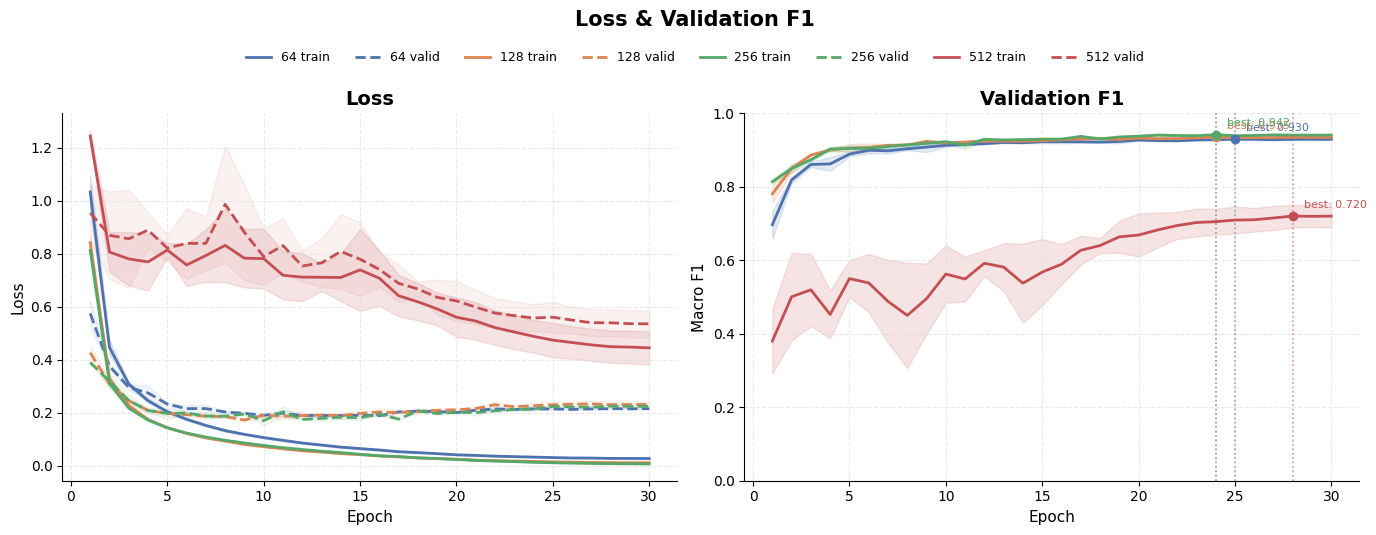

In [23]:
plot_loss_and_f1_curves(transformer_dmodel_results, group_name='')

In [9]:
summary_df = build_summary_df({
    f'pooling={p}': {'mfcc': v}
    for p, v in transformer_dmodel_results.items()
})
plot_summary_table(summary_df)

,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,pooling=64,mfcc,0.9550 ± 0.0008,0.001,0.9051 ± 0.0054,0.006,0.9561 ± 0.0005,0.001
1,pooling=128,mfcc,0.9608 ± 0.0003,0.000,0.9126 ± 0.0031,0.003,0.9617 ± 0.0007,0.001
2,pooling=256,mfcc,0.9627 ± 0.0020,0.002,0.9161 ± 0.0033,0.004,0.9636 ± 0.0019,0.002
3,pooling=512,mfcc,0.8287 ± 0.0128,0.015,0.7090 ± 0.0173,0.024,0.8247 ± 0.0142,0.017


,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,pooling=64,mfcc,0.9550 ± 0.0008,0.001,0.9051 ± 0.0054,0.006,0.9561 ± 0.0005,0.001
1,pooling=128,mfcc,0.9608 ± 0.0003,0.000,0.9126 ± 0.0031,0.003,0.9617 ± 0.0007,0.001
2,pooling=256,mfcc,0.9627 ± 0.0020,0.002,0.9161 ± 0.0033,0.004,0.9636 ± 0.0019,0.002
3,pooling=512,mfcc,0.8287 ± 0.0128,0.015,0.7090 ± 0.0173,0.024,0.8247 ± 0.0142,0.017


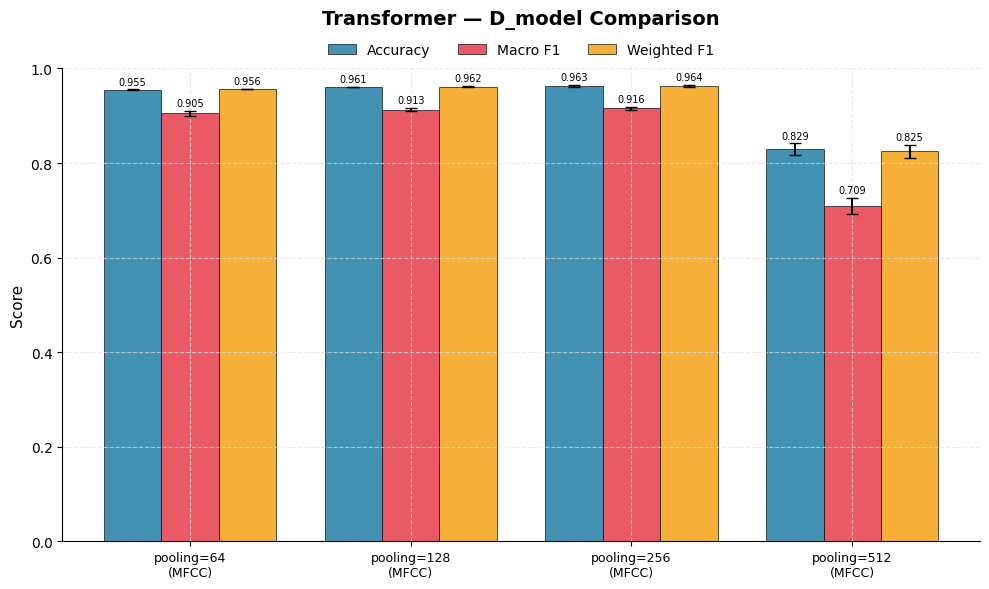

In [24]:
plot_metrics_comparison(summary_df, title='Transformer — D_model Comparison')

In [13]:
embeddings_per_dmodel = {}
for dmodel in D_MODELS:
    print(f'Extracting embeddings for dmodel={dmodel}...')
    model = get_best_model(transformer_dmodel_results, dmodel)
    embeddings, labels = extract_embeddings(model, test_cached, device)
    embeddings_per_dmodel[dmodel] = {'embs': embeddings, 'labels': labels}
    print(f'  -> shape: {embeddings.shape}')

Extracting embeddings for dmodel=64...
  -> shape: (6865, 64)
Extracting embeddings for dmodel=128...
  -> shape: (6865, 128)
Extracting embeddings for dmodel=256...
  -> shape: (6865, 256)
Extracting embeddings for dmodel=512...
  -> shape: (6865, 512)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


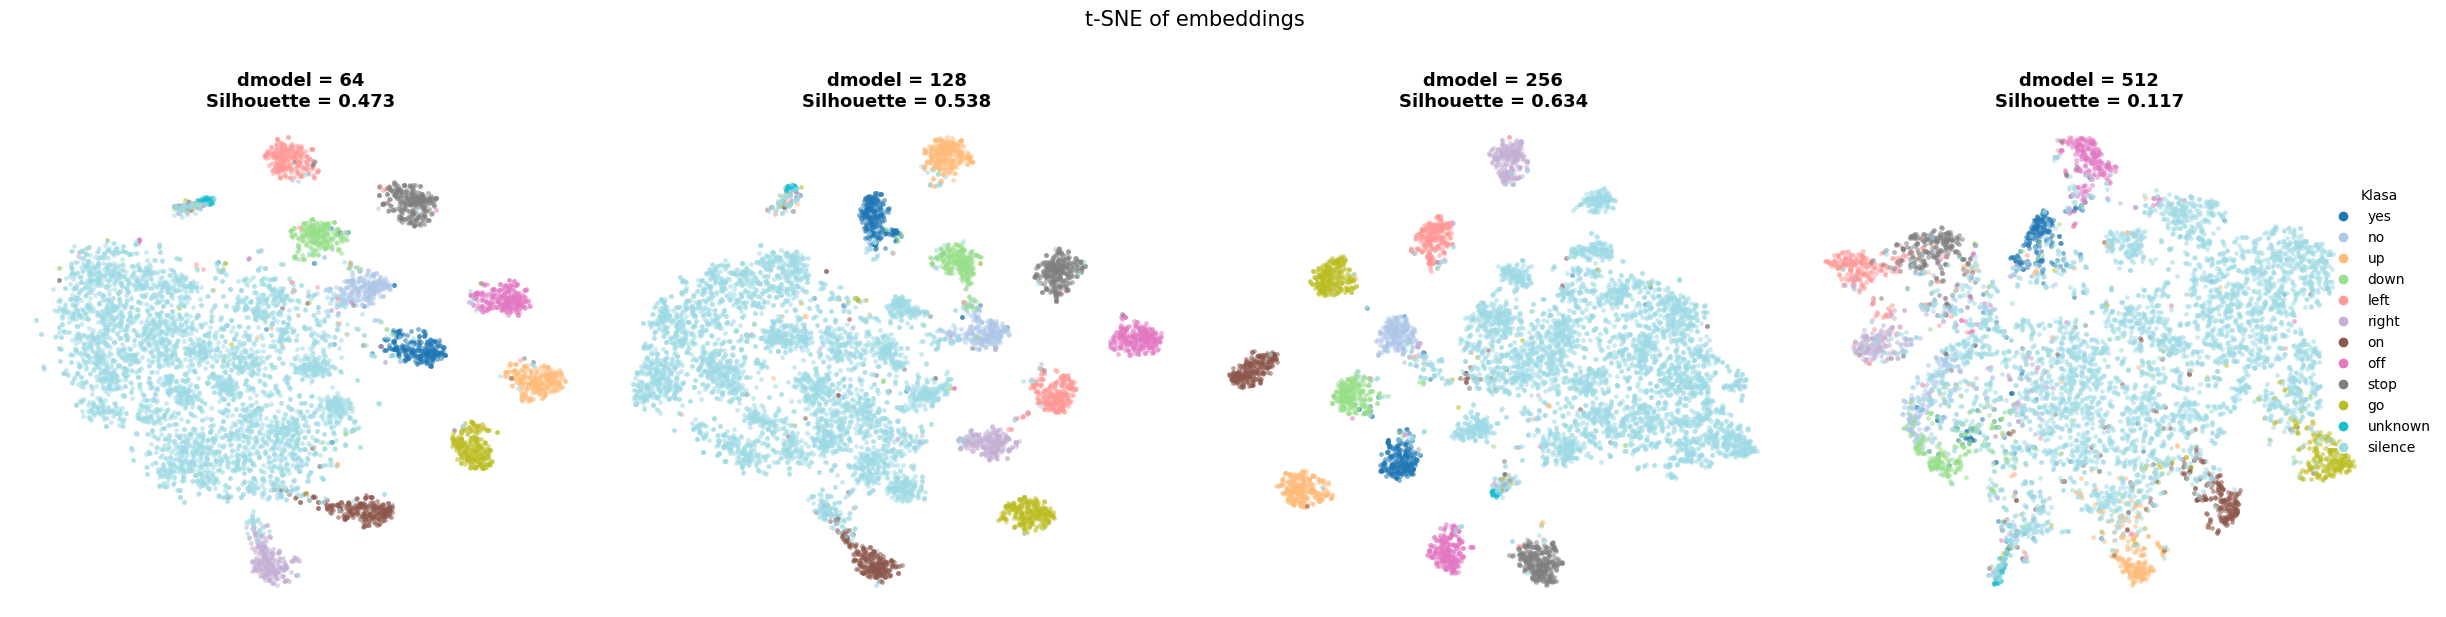

In [15]:
plot_tsne_comparison(embeddings_per_dmodel, CLASS_NAMES, key_label='dmodel')


 dmodel=64, seed=1, F1=0.9127


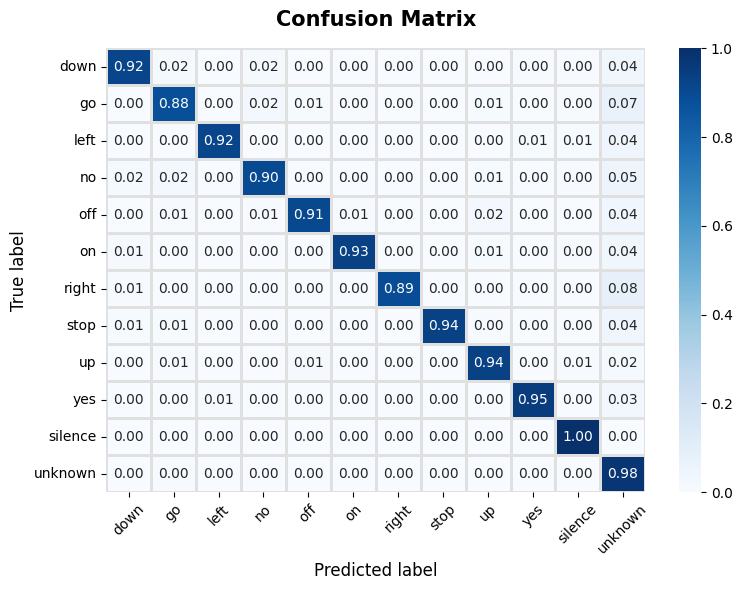


 dmodel=128, seed=1, F1=0.9152


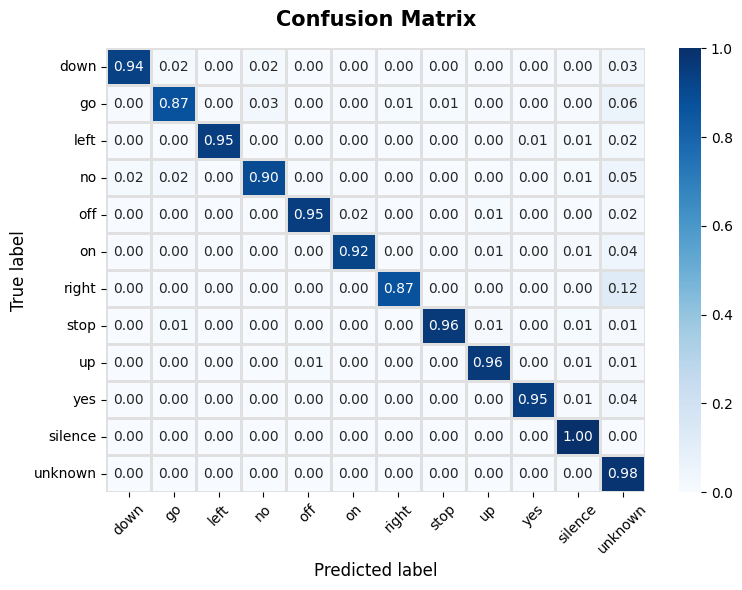


 dmodel=256, seed=2, F1=0.9197


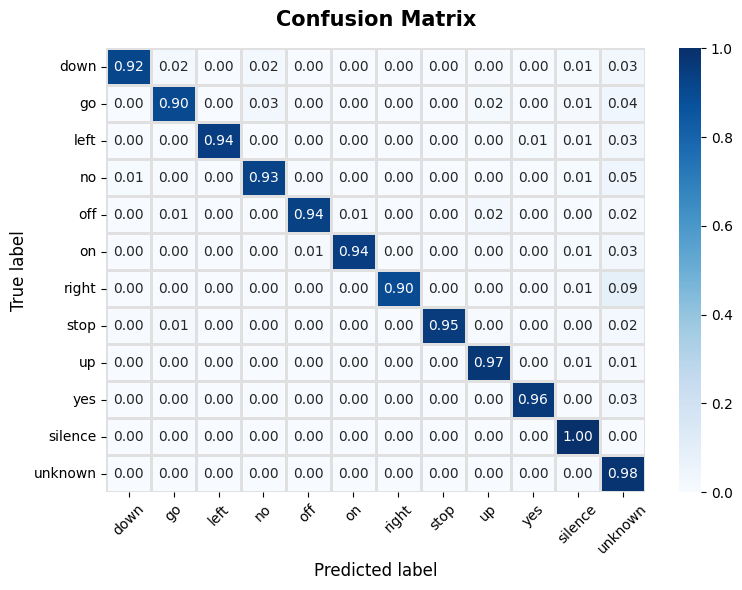


 dmodel=512, seed=1, F1=0.7335


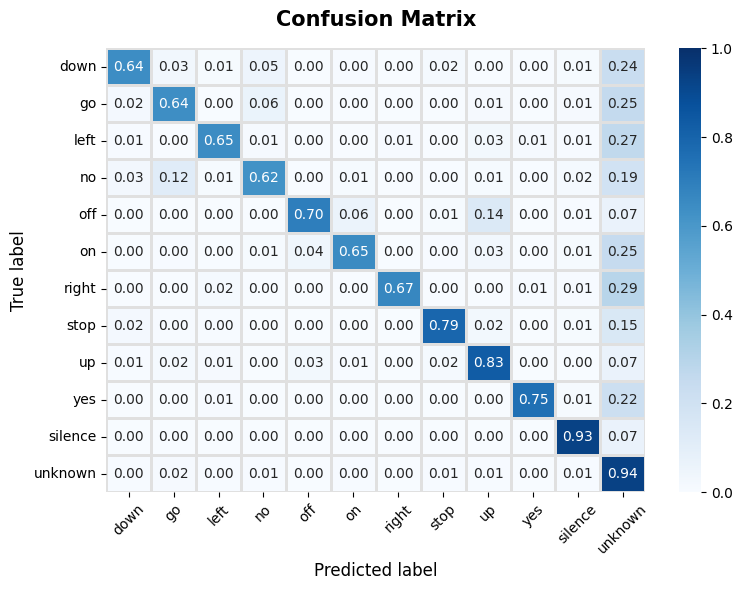

In [16]:
for dmodel in D_MODELS:
    best_seed = max(transformer_dmodel_results[dmodel], key=lambda s: transformer_dmodel_results[dmodel][s]['test_macro_f1'])
    best_result = transformer_dmodel_results[dmodel][best_seed]
    print(f'\n dmodel={dmodel}, seed={best_seed}, F1={best_result["test_macro_f1"]:.4f}')
    plot_confusion_matrix(best_result['test_cm'])

### CNN Transformer

In [ ]:
cnn_transformer_dmodel_results = run_dmodel_experiment(model_factory=cnn_transformer_dmodel_factory,
    d_models=D_MODELS, seeds=SEEDS, model_name='CNNTransformer')

In [25]:
plot_loss_and_f1_curves(cnn_transformer_dmodel_results, group_name='')

NameError: name 'cnn_transformer_dmodel_results' is not defined

In [36]:
summary_df = build_summary_df({
    f'pooling={p}': {'mfcc': v}
    for p, v in cnn_transformer_dmodel_results.items()
})
plot_summary_table(summary_df)

,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,pooling=mean,mfcc,0.9690 ± 0.0008,0.001,0.9554 ± 0.0014,0.001,0.9688 ± 0.0009,0.001
1,pooling=attention_pooling_linear,mfcc,0.9699 ± 0.0004,0.000,0.9553 ± 0.0015,0.002,0.9698 ± 0.0004,0.000
2,pooling=attention_pooling_sequential,mfcc,0.9695 ± 0.0019,0.002,0.9554 ± 0.0025,0.003,0.9694 ± 0.0020,0.002


,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,pooling=mean,mfcc,0.9690 ± 0.0008,0.001,0.9554 ± 0.0014,0.001,0.9688 ± 0.0009,0.001
1,pooling=attention_pooling_linear,mfcc,0.9699 ± 0.0004,0.000,0.9553 ± 0.0015,0.002,0.9698 ± 0.0004,0.000
2,pooling=attention_pooling_sequential,mfcc,0.9695 ± 0.0019,0.002,0.9554 ± 0.0025,0.003,0.9694 ± 0.0020,0.002


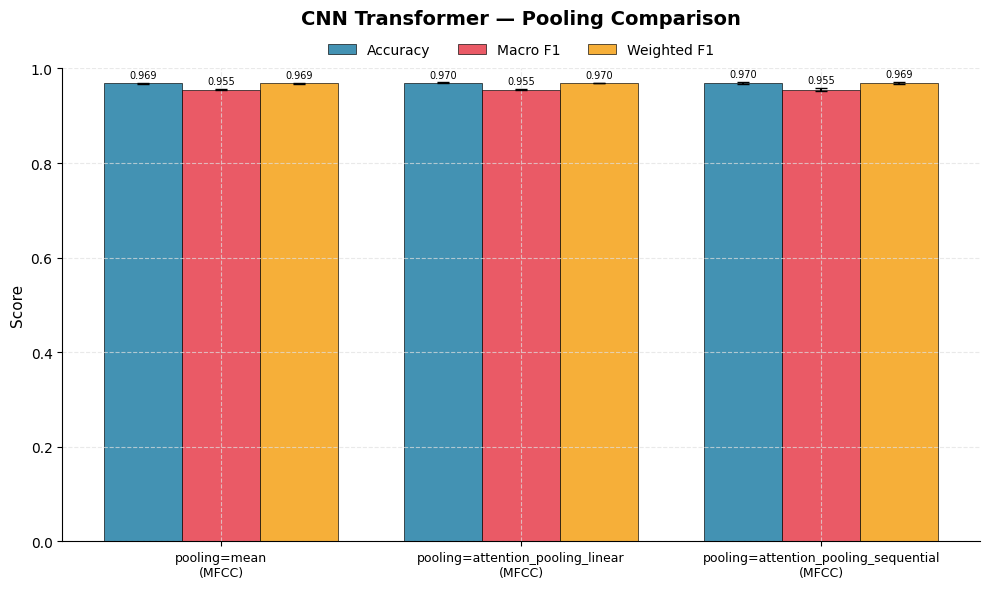

In [37]:
plot_metrics_comparison(summary_df, title='CNN Transformer — D_model Comparison')

In [41]:
embeddings_per_dmodel = {}
for dmodel in D_MODELS:
    print(f'Extracting embeddings for dmodel={dmodel}...')
    model = get_best_model(cnn_transformer_dmodel_results, dmodel)
    embeddings, labels = extract_embeddings(model, test_cached, device)
    embeddings_per_dmodel[dmodel] = {'embs': embeddings, 'labels': labels}
    print(f'  -> shape: {embeddings.shape}')

Extracting embeddings for pooling=mean...
  -> shape: (6865, 128)
Extracting embeddings for pooling=attention_pooling_linear...
  -> shape: (6865, 128)
Extracting embeddings for pooling=attention_pooling_sequential...
  -> shape: (6865, 128)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


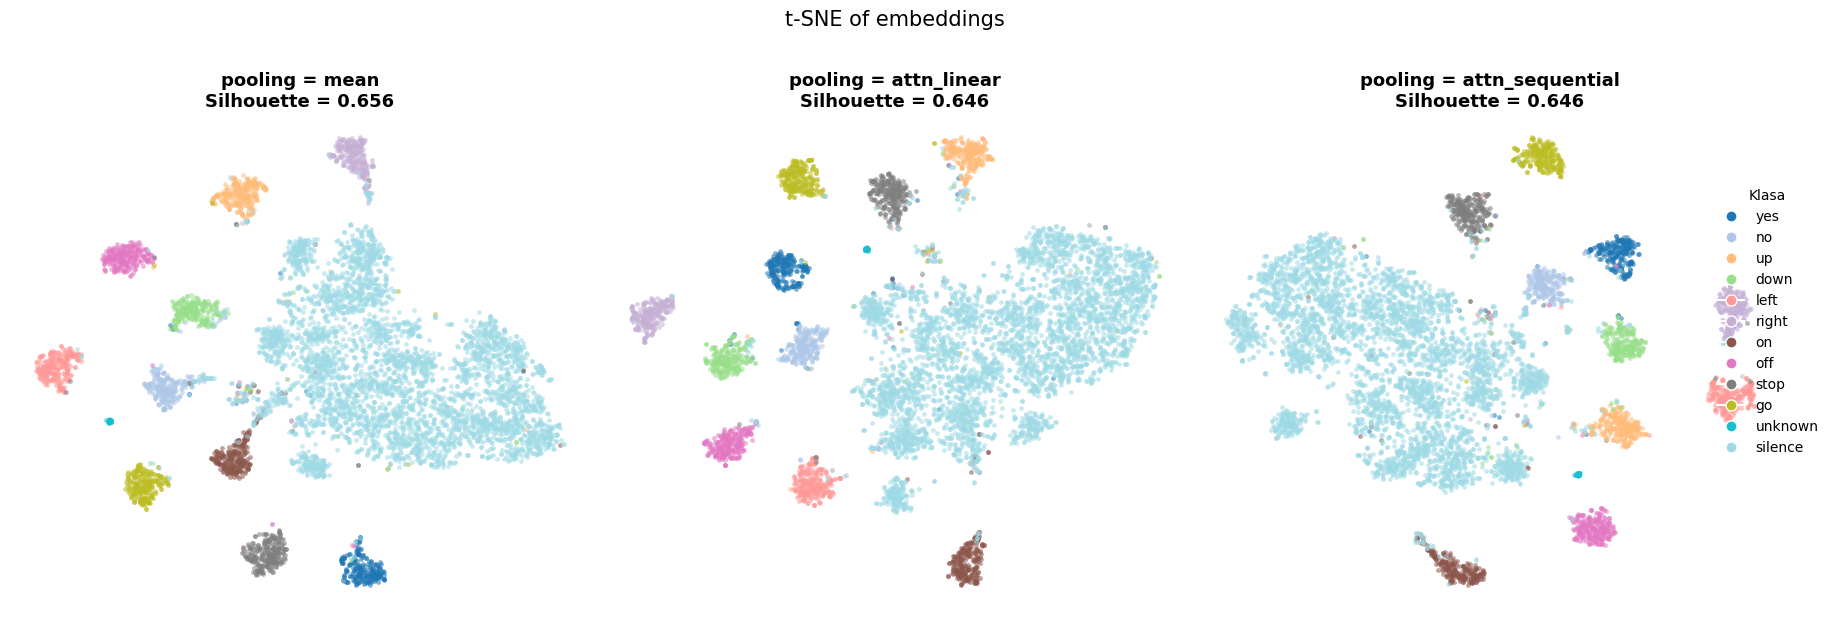

In [42]:
plot_tsne_comparison(embeddings_per_pooling, CLASS_NAMES, key_label='dmodel')


pooling=mean, seed=2, F1=0.9566


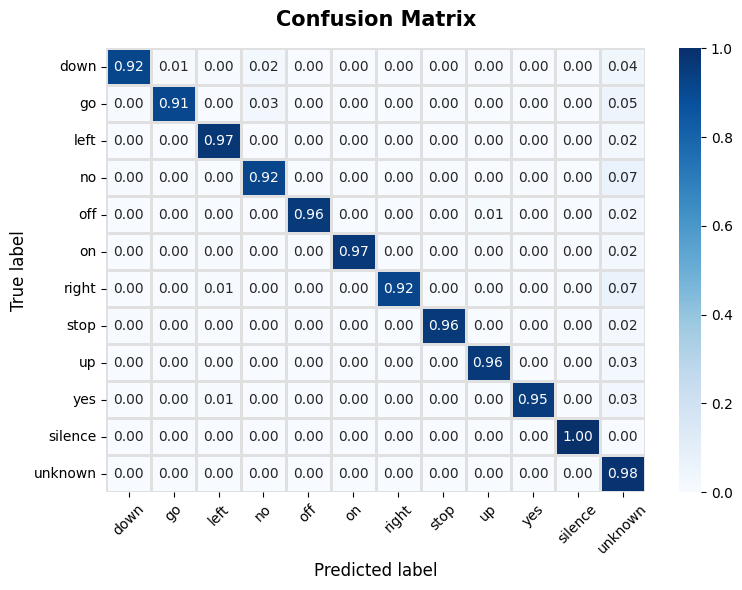


pooling=attn_linear, seed=2, F1=0.9572


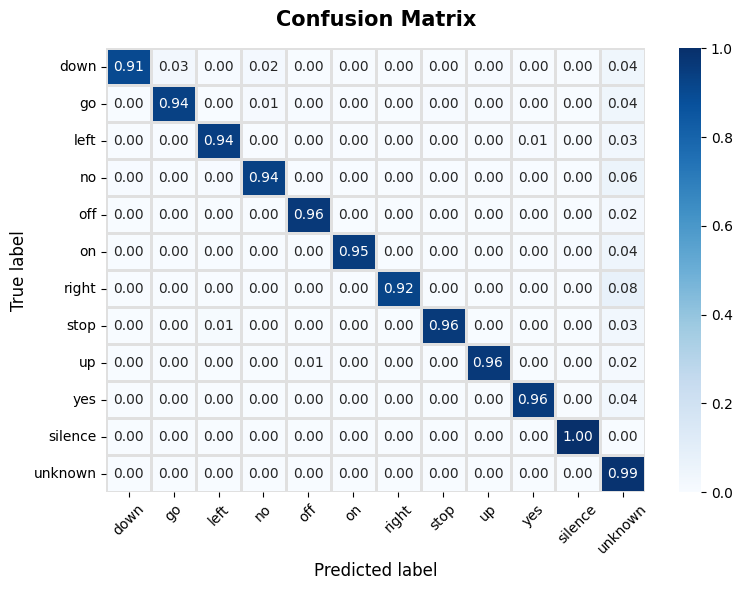


pooling=attn_sequential, seed=2, F1=0.9585


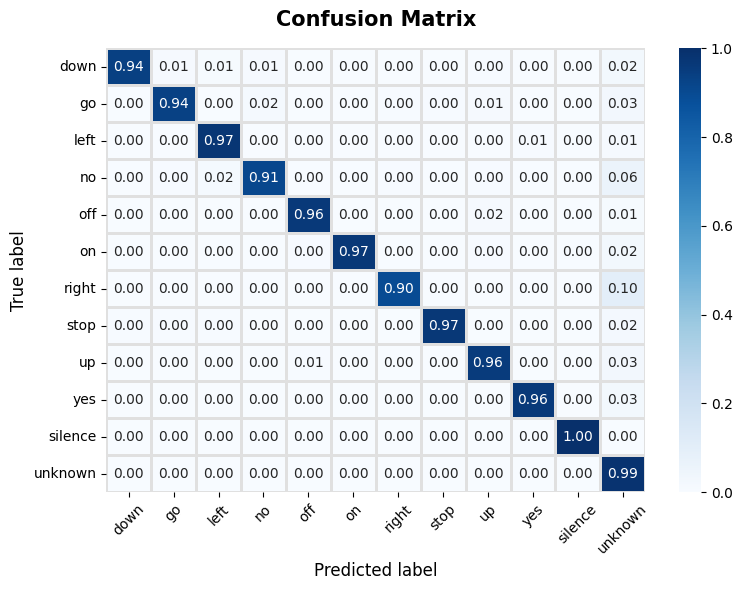

In [47]:
for dmodel in D_MODELS:
    best_seed = max(cnn_transformer_dmodel_results[dmodel], key=lambda s: cnn_transformer_dmodel_results[dmodel][s]['test_macro_f1'])
    best_result = cnn_transformer_dmodel_results[dmodel][best_seed]
    print(f'\n dmodel={dmodel}, seed={best_seed}, F1={best_result["test_macro_f1"]:.4f}')
    plot_confusion_matrix(best_result['test_cm'])